In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random
import torch

import warnings
warnings.filterwarnings("ignore")

In [3]:
#----------------------------- DON'T CHANGE THIS --------------------------
DATA_SEED = 67
TRAINING_SEED = 1234
SR = 22050
DURATION = 5.0
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
TOP_DB=20
TARGET_SNR_DB = 10

random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)
torch.cuda.manual_seed(DATA_SEED)

In [4]:
# CONFIGURATION
DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"  # Enter dataset path
GENRES = ["blues","classical","country","disco","hiphop","jazz","metal","pop","reggae","rock"]  # Make the list of all genres available (alphabetical order)
STEMS = {"drums": "drums.wav",
    "vocals": "vocals.wav",
    "bass": "bass.wav",
    "other": "other.wav"}    # Write here stems file name
STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
GENRE_TO_TEST = 'rock'
SONG_INDEX = 0 #Enter index as per Q10.

In [5]:
def build_dataset(root_dir, val_split=0.17, seed=42):
    # Initialize empty dictionaries
    train_dataset = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
    val_dataset   = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}

    rng = random.Random(seed)

    # ------------------- write your code here -------------------------------

    import os

    for genre in GENRES:
        genre_path = os.path.join(root_dir, "genres_stems", genre)
    
        # Skip if folder missing
        if not os.path.isdir(genre_path):
            continue
    
        songs = sorted(os.listdir(genre_path))
        valid_songs = []
    
        # --- check each song folder ---
        for song in songs:
            song_path = os.path.join(genre_path, song)
    
            if not os.path.isdir(song_path):
                continue
    
            stem_paths = {}
            corrupted = False
    
            # Check stems exist and are not corrupted
            for key in STEM_KEYS:
                file_name = STEMS[key]
                file_path = os.path.join(song_path, file_name)
    
                if not os.path.isfile(file_path):
                    corrupted = True
                    break
    
                # check file size (corruption test)
                if os.path.getsize(file_path) < 4 * 1024:
                    corrupted = True
                    break
    
                stem_paths[key] = file_path
    
            if not corrupted:
                valid_songs.append(stem_paths)
    
        # --- shuffle songs reproducibly ---
        rng.shuffle(valid_songs)
    
        # --- split into train / validation ---
        split_idx = int(len(valid_songs) * (1 - val_split))
        train_songs = valid_songs[:split_idx]
        val_songs   = valid_songs[split_idx:]
    
        # --- helper function to populate dict ---
        def add_to_dict(target_dict, song_list):
            for song in song_list:
                for stem_key, path in song.items():
                    target_dict[genre][stem_key].append(path)
    
        add_to_dict(train_dataset, train_songs)
        add_to_dict(val_dataset, val_songs)

    
        # Iterate through Genres
        # Check: if genre folder exists
        # CHECK : Completeness (Does it have all stems?)
        # CHECK : Corruption (Is any file too small? (less than 4kb))
        # size checks
        # Stratified Shuffle Split
     #-------------------------------------------------------------------------

        # Helper function to populate dict
        def add_to_dict(target_dict, song_list):
            pass

    return train_dataset, val_dataset

tr, val = build_dataset(DATA_ROOT)

In [6]:
#Q1

import librosa
import numpy as np

durations = []

for stem_name, file_list in tr["jazz"].items():
    for path in file_list:
        try:
            y, sr = librosa.load(path, sr=None)
            durations.append(len(y)/sr)
        except:
            continue

print(round(np.mean(durations), 2))

30.03


In [7]:
#Q2

import librosa

sample_rates = set()

for genre in tr:
    for stem in tr[genre]:
        for path in tr[genre][stem]:
            try:
                _, sr = librosa.load(path, sr=None)
                sample_rates.add(sr)
            except:
                continue

print(sorted(sample_rates))

[44100]


In [6]:
#Q2 (Alt)

import soundfile as sf

sample_rates = set()

for genre in tr:
    for stem in tr[genre]:
        for path in tr[genre][stem]:
            try:
                info = sf.info(path)
                sample_rates.add(info.samplerate)
            except:
                continue

print(sorted(sample_rates))

[44100]


In [8]:
#Q3 

import os

corrupted = 0

for genre in tr:
    for stem in tr[genre]:
        for path in tr[genre][stem]:
            try:
                if os.path.getsize(path) == 0:
                    corrupted += 1
            except:
                corrupted += 1

print("Corrupted files:", corrupted)

Corrupted files: 0


In [10]:
#Q4

import librosa
import numpy as np

peak_db_vals = []

for genre in tr:
    for path in tr[genre]["vocals"]:
        try:
            y, sr = librosa.load(path, sr=None)
            peak = np.max(np.abs(y))
            if peak > 0:
                peak_db_vals.append(20 * np.log10(peak))
        except:
            continue

print(round(np.mean(peak_db_vals), 2))

-12.42


In [11]:
#Q5

import librosa
import numpy as np

centroids = []

for stem in tr["blues"]:
    for path in tr["blues"][stem]:
        try:
            y, sr = librosa.load(path, sr=None)
            sc = librosa.feature.spectral_centroid(y=y, sr=sr)
            centroids.append(np.mean(sc))
        except:
            continue

print(round(np.mean(centroids), 2))

2324.45


In [ ]:
#Q6

import librosa
import numpy as np

genre_centroids = {}

for genre in tr:
    vals = []
    for stem in tr[genre]:
        for path in tr[genre][stem]:
            try:
                y, sr = librosa.load(path, sr=None)
                sc = librosa.feature.spectral_centroid(y=y, sr=sr)
                vals.append(np.mean(sc))
            except:
                continue
    
    if vals:
        genre_centroids[genre] = np.mean(vals)

print(max(genre_centroids, key=genre_centroids.get))

In [13]:
#Q7

import librosa
import numpy as np

silent_count = 0

for genre in tr:
    for stem in tr[genre]:
        for path in tr[genre][stem]:
            try:
                y, sr = librosa.load(path, sr=None, duration=0.5)
                
                # if max amplitude very small → silence
                if np.max(np.abs(y)) < 1e-3:
                    silent_count += 1
                    
            except:
                continue

print(silent_count)

450


**Section - 2**

Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



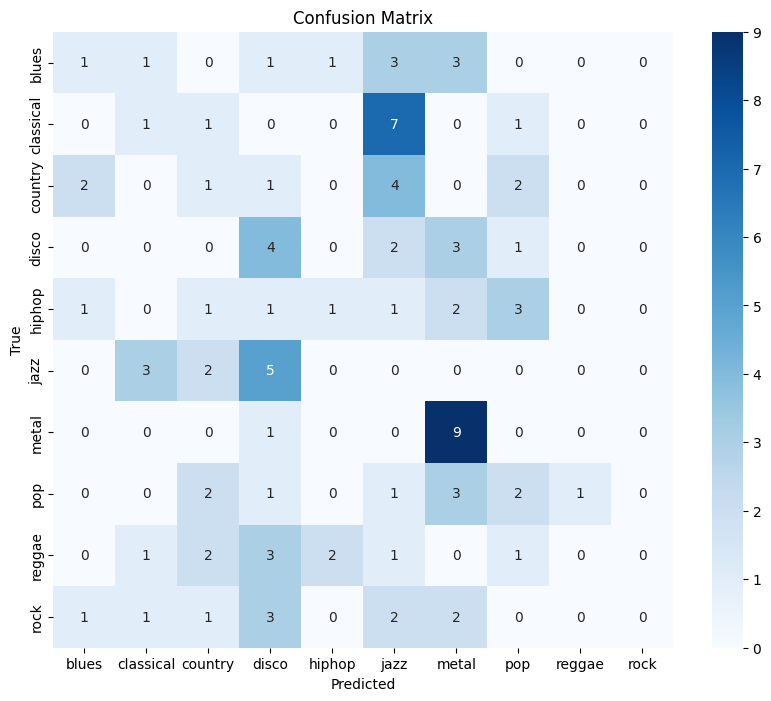


Per-genre metrics:
           TP  FN  FP  TN
blues       1   9   4  86
classical   1   9   6  84
country     1   9   9  81
disco       4   6  16  74
hiphop      1   9   3  87
jazz        0  10  21  69
metal       9   1  13  77
pop         2   8   8  82
reggae      0  10   1  89
rock        0  10   0  90


In [14]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)


# --- Evaluation ---
y_pred = clf.predict(X_val)

macro_f1 = f1_score(y_val, y_pred, average='macro')

cm = confusion_matrix(y_val, y_pred, labels=GENRES)

cr = classification_report(y_val, y_pred, target_names=GENRES, output_dict=True)
cr_text = classification_report(y_val, y_pred, target_names=GENRES)


print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr_text)


# Visualize confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=GENRES, yticklabels=GENRES, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Compute TP, FN, FP, TN per genre
metrics = {}

total = np.sum(cm)

for i, genre in enumerate(GENRES):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = total - TP - FN - FP
    
    metrics[genre] = {"TP": TP, "FN": FN, "FP": FP, "TN": TN}

metrics_df = pd.DataFrame(metrics).T
print("\nPer-genre metrics:")
print(metrics_df)